In [1]:
import numpy as np

In [50]:
model = "xlm-roberta-base"
model_family = 'xlm'
vocab_file = f'vocab/{model_family}_vocab.npy'
vocab = np.load(vocab_file, allow_pickle=True)
vocab_categories_file = f'vocab/{model_family}_categories.npy'
vocab_categories = np.load(vocab_categories_file, allow_pickle=True)
map_file = f'vocab/m_x_u_{model_family}_map.npy'
vocab_map = np.load(map_file, allow_pickle=True)

subset_vocab = vocab[vocab_map]
subset_vocab_categories = vocab_categories[vocab_map]

In [51]:
subset_vocab_categories # y

array(['LATIN', 'M', 'LATIN', ..., 'LATIN', 'LATIN', 'LATIN'],
      dtype='<U17')

In [52]:
subset_vocab_categories.shape

(78732,)

In [53]:
import torch

embeddings_file = f"./{model}/embeddings.pt"
embeddings = torch.load(embeddings_file)
subset_embeddings = embeddings[vocab_map,:].float()
row_norms = torch.norm(subset_embeddings, dim=1)

subset_embeddings = torch.div(subset_embeddings, row_norms.reshape(-1, 1))

In [54]:
subset_embeddings.shape # x

torch.Size([78732, 768])

In [55]:
vocab_map.shape

(78732,)

## linear classifier

In [56]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
from sklearn.model_selection import cross_val_score

In [26]:
np.unique(subset_vocab_categories)

array(['ARABIC', 'ARMENIAN', 'BENGALI', 'BOPOMOFO', 'C', 'CANADIAN',
       'CARON', 'CJK', 'CYRILLIC', 'DEVANAGARI', 'ETHIOPIC', 'GEORGIAN',
       'GREEK', 'GUJARATI', 'GURMUKHI', 'HANGUL', 'HEBREW', 'HIRAGANA',
       'IDEOGRAPHIC', 'KANNADA', 'KATAKANA', 'KATAKANA-HIRAGANA', 'KHMER',
       'LAO', 'LATIN', 'M', 'MALAYALAM', 'MODIFIER', 'MONGOLIAN',
       'MYANMAR', 'N', 'NKO', 'ORIYA', 'P', 'S', 'SINHALA', 'SYRIAC',
       'TAMIL', 'TELUGU', 'THAI', 'TIBETAN'], dtype='<U17')

In [43]:
import variables

In [44]:
variables.CATEGORIES

['LATIN',
 'CYRILLIC',
 'CJK',
 'ARABIC',
 'GREEK',
 'HIRAGANA',
 'THAI',
 'HEBREW',
 'HANGUL',
 'KATAKANA',
 'TAMIL',
 'GEORGIAN',
 'DEVANAGARI']

In [57]:
X = subset_embeddings
y = subset_vocab_categories
# define model
model = LogisticRegression()

print("CATEGORY\tSIZE\tMEAN(score)\tSTD(score)")
for category in variables.CATEGORIES:
    y = np.array([1 if s == category else 0 for s in subset_vocab_categories])
    rus = RandomUnderSampler(random_state=150)
    X_resampled, y_resampled = rus.fit_resample(X, y)
    scores = cross_val_score(model, X_resampled, y_resampled, cv=10)
    print(f"{category}\t{len(y_resampled)}\t{np.mean(scores):.3f}\t{np.std(scores):.3f}")
#     print(sorted(Counter(y_resampled).items()))

CATEGORY	SIZE	MEAN(score)	STD(score)
LATIN	78140	0.998	0.001
CYRILLIC	16666	0.999	0.001
CJK	18044	0.991	0.001
ARABIC	6404	0.999	0.001
GREEK	3892	0.999	0.001
HIRAGANA	3290	0.988	0.005
THAI	2610	0.998	0.004
HEBREW	2978	1.000	0.001
HANGUL	4720	0.998	0.002
KATAKANA	1404	0.981	0.010
TAMIL	1338	0.999	0.002
GEORGIAN	1072	1.000	0.000
DEVANAGARI	2146	0.997	0.002


In [72]:
s = """
CATEGORY	SIZE	MEAN(accuracy)	STD(accuracy)	MODEL
LATIN	78140	0.990	0.001	mt5-base
CYRILLIC	16666	0.929	0.006	mt5-base
CJK	18044	0.968	0.003	mt5-base
ARABIC	6404	0.935	0.010	mt5-base
GREEK	3892	0.946	0.009	mt5-base
HIRAGANA	3290	0.979	0.006	mt5-base
THAI	2610	0.957	0.011	mt5-base
HEBREW	2978	0.942	0.012	mt5-base
HANGUL	4720	0.953	0.012	mt5-base
KATAKANA	1404	0.981	0.012	mt5-base
TAMIL	1338	0.925	0.018	mt5-base
GEORGIAN	1072	0.918	0.022	mt5-base
DEVANAGARI	2146	0.955	0.012	mt5-base
LATIN	78140	0.998	0.001	xlm-roberta-base
CYRILLIC	16666	0.999	0.001	xlm-roberta-base
CJK	18044	0.991	0.001	xlm-roberta-base
ARABIC	6404	0.999	0.001	xlm-roberta-base
GREEK	3892	0.999	0.001	xlm-roberta-base
HIRAGANA	3290	0.988	0.005	xlm-roberta-base
THAI	2610	0.998	0.004	xlm-roberta-base
HEBREW	2978	1.000	0.001	xlm-roberta-base
HANGUL	4720	0.998	0.002	xlm-roberta-base
KATAKANA	1404	0.981	0.010	xlm-roberta-base
TAMIL	1338	0.999	0.002	xlm-roberta-base
GEORGIAN	1072	1.000	0.000	xlm-roberta-base
DEVANAGARI	2146	0.997	0.002	xlm-roberta-base
"""

In [73]:
import pandas as pd
from io import StringIO
TESTDATA = StringIO("""col1;col2;col3
    1;4.4;99
    2;4.5;200
    3;4.7;65
    4;3.2;140
    """)

df = pd.read_csv(StringIO(s), sep="\t")


(0.9, 1.01)

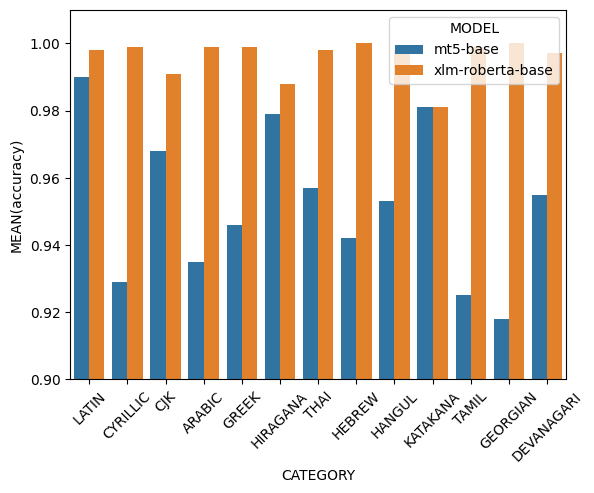

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.barplot(data=df, x='CATEGORY', y='MEAN(accuracy)', hue='MODEL')
plt.xticks(rotation=45)
plt.ylim(0.9, 1.01)

In [42]:
# from sklearn.utils import shuffle
# X_resampled_shuffled, y_resampled_shuffled = shuffle(X_resampled, y_resampled, random_state=0)
# cross_val_score(model, X_resampled, np.random.permutation(y_resampled), cv=5) # sanity check
# cross_val_score(model, X_resampled_shuffled, y_resampled_shuffled, cv=5) # sanity check


array([0.98976197, 0.99027387, 0.98944203, 0.99046583, 0.98809829])